Created on 01/07/26

This file contains the script for applying clustering techniques to the data used for the deterministic scheduling and planning applcations.

Clustering approaches considered:
- KMeans (from scikit learn)
- KMedoids (from scikit learn extra)
- KMeans with subsequent data scaling to match overall generation/consumption/prices
- KMedoids with subsequent data scaling to match overall generation/consumption/prices

The "Control panel" below can be used to run either everything or a selected number of cells.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids


# Control panel --------------------------------------------
# Example: Kmeans + scaling the data --> run_kmeans = True, run_scaledata = True
run_all = True          # run everything
run_kmeans = False
run_kmedoids = False
run_scaledata = False

#### Gathering the original data

In [13]:
# Sizes -----------------------------------------------------------------------------------------
Pl_comm_rtd = 1     # rated commertial load power [MW]
Pl_ind_rtd = 1      # rated industrial load power [MW]
Pl_resid_rtd = 1    # rated residential load power [MW]

Ppv_rtd = 3    # PV rated power [MW]

#------------------------------------------------------------------------------------------------
# PROFILES
#------------------------------------------------------------------------------------------------

# Reading the Excel files
C_ele_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\GME_20240101_20241231_MGP_PrezziZonali_CSUD.xlsx", decimal=',')
Pl_Ppv_Pwt_original = pd.read_excel(r"C:\Users\massi\Università_user\Dottorato\Materiale\Periodo all'estero - Svizzera\Work\Case Definition\Simulation data\Profiles\Dati ENEA.xlsx")

# Extraction of useful profiles
C_ele_full = C_ele_original['€/MWh'].tolist()               # zonal price (CSUD 2024) [€/MWh], from 01/01/24 to 31/12/24 (leap year, 366 days)
C_ele = np.array(C_ele_full[:1416] + C_ele_full[1440:])     # removing 29th Feb data to have 365 days (8760 hours) and turning into ndarray

C_ele_sell = C_ele / 2

Pl_comm_to_arrange = Pl_Ppv_Pwt_original['Commerciale'].tolist()            # commercial load profile [p.u.], from 16/10/20 to 15/10/21
Pl_comm = np.array(Pl_comm_to_arrange[1848:] + Pl_comm_to_arrange[:1848])   # rearranged data from 01/01/21 to 15/10/21 and then from 16/10/20 to 31/12/20

Pl_ind_to_arrange = Pl_Ppv_Pwt_original['Industriale'].tolist()             # industrial load profile [p.u.], from 16/10/20 to 15/10/21
Pl_ind = np.array(Pl_ind_to_arrange[1848:] + Pl_ind_to_arrange[:1848])

Pl_resid_to_arrange = Pl_Ppv_Pwt_original['Residenziale'].tolist()          # residential load profile [p.u.], from 16/10/20 to 15/10/21
Pl_resid = np.array(Pl_resid_to_arrange[1848:] + Pl_resid_to_arrange[:1848])

Ppv_to_arrange = Pl_Ppv_Pwt_original['PV'].tolist()         # PV generation profile [??], from 16/10/20 to 15/10/21
P_pv = np.array(Ppv_to_arrange[1848:] + Ppv_to_arrange[:1848])

Pwt_to_arrange = Pl_Ppv_Pwt_original['Wind'].tolist()       # WT generation profile [??], from 16/10/20 to 15/10/21
P_wt = np.array(Pwt_to_arrange[1848:] + Pwt_to_arrange[:1848])

# Profiles adjustments based on rated powers
Pl_comm = Pl_comm * Pl_comm_rtd         # Commercial load profile [MW]
Pl_ind = Pl_ind * Pl_ind_rtd            # Industrial load profile [MW]
Pl_resid = Pl_resid * Pl_resid_rtd      # Residential load profile [MW]
P_load = Pl_ind + Pl_comm              # load profile used in the optimization problem [MW]
P_pv = (P_pv / 2) * Ppv_rtd             # PV generation profile [MW]
# P_wt = P_wt * Pwt_rtd                   # WT generation profile [MW]


# Checking the data ------
time = np.arange(0, 8760)

# Plot settings
plt.rc('figure', figsize=(20, 20))
plt.rc('font', family='monospace', weight='bold', size=11)
plt.rc('axes', labelsize=11, titlesize=14)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)
plt.rcParams['axes.grid'] = True
plt.rcParams['lines.linewidth'] = 2

"""
# Checking the data after adjustments
fig, axs = plt.subplots(6, 1, layout='constrained')
axs[0].plot(time, C_ele, color='blue')
axs[0].set_xlabel('x label')
axs[0].set_ylabel('y label')
axs[0].set_title("Electricity Price [€/MWh]")
axs[0].legend()

axs[1].plot(time, Pl_comm)
axs[1].set_title("Commercial load [MW]")
axs[2].plot(time, Pl_ind)
axs[2].set_title("Industrial load [MW]")
axs[3].plot(time, Pl_resid)
axs[3].set_title("Residential load [MW]")
axs[4].plot(time, P_pv)
axs[4].set_title("PV generation [MW]")
# axs[5].plot(time, P_wt)
# axs[5].set_title("WT generation")
"""

# print(P_pv)

'\n# Checking the data after adjustments\nfig, axs = plt.subplots(6, 1, layout=\'constrained\')\naxs[0].plot(time, C_ele, color=\'blue\')\naxs[0].set_xlabel(\'x label\')\naxs[0].set_ylabel(\'y label\')\naxs[0].set_title("Electricity Price [€/MWh]")\naxs[0].legend()\n\naxs[1].plot(time, Pl_comm)\naxs[1].set_title("Commercial load [MW]")\naxs[2].plot(time, Pl_ind)\naxs[2].set_title("Industrial load [MW]")\naxs[3].plot(time, Pl_resid)\naxs[3].set_title("Residential load [MW]")\naxs[4].plot(time, P_pv)\naxs[4].set_title("PV generation [MW]")\n# axs[5].plot(time, P_wt)\n# axs[5].set_title("WT generation")\n'

#### Rearranging the data into a $N*(TM)$ matrix
$N$ is the number of samples (in this case, the 365 days), $T$ is the number of timesteps in a single day, and $M$ is the number of input data types to consider (in this case, three: PV generation, load consumption, and electricity prices); $T*M$ i the total number of features defining each datapoint.

In [14]:
# Reshaping the (8760, 1) arrays into (365, 24) matrices ---------------
C_ele_mat = np.reshape(copy.copy(C_ele), (365, 24))
C_ele_sell_mat = np.reshape(copy.copy(C_ele_sell), (365, 24))
P_load_mat = np.reshape(copy.copy(P_load), (365, 24))
P_pv_mat = np.reshape(copy.copy(P_pv), (365, 24))

# Normalizing the data for each type of input -----------------------
inputs_tuple = (C_ele_mat, C_ele_sell_mat, P_load_mat, P_pv_mat)
maximums_list = []
for input in inputs_tuple:
    maximum = np.max(input)
    maximums_list.append(maximum)    # list of the maximum values for each type of input
    input /= maximum

# Connecting the matrices side by side to obtain a single (365, 24*4) matrix -------------------------
dataset_for_clustering = np.concatenate((C_ele_mat, C_ele_sell_mat, P_load_mat, P_pv_mat), axis=1)

# Separating the data by month --------------------
Dnum = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] 
dset_jan = dataset_for_clustering[0:31, :]
dset_feb = dataset_for_clustering[31:59, :]
dset_mar = dataset_for_clustering[59:90, :]
dset_apr = dataset_for_clustering[90:120, :]
dset_may = dataset_for_clustering[120:151, :]
dset_jun = dataset_for_clustering[151:181, :]
dset_jul = dataset_for_clustering[181:212, :]
dset_aug = dataset_for_clustering[212:243, :]
dset_sep = dataset_for_clustering[243:273, :]
dset_oct = dataset_for_clustering[273:304, :]
dset_nov = dataset_for_clustering[304:334, :]
dset_dec = dataset_for_clustering[334:365, :]    # TODO: cambiare ultimo indice in 365 dopo le prove preliminari

monthly_data_tuple = (dset_jan, dset_feb, dset_mar, dset_apr, dset_may, dset_jun,
                      dset_jul, dset_aug, dset_sep, dset_oct, dset_nov, dset_dec)
months_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

### KMeans Clustering

Inertia for Jan = 26.750601591297972
Inertia for Feb = 25.07296783407361
Inertia for Mar = 37.34046481393652
Inertia for Apr = 32.11771306607873
Inertia for May = 31.413529561721155
Inertia for Jun = 28.30511967657148
Inertia for Jul = 29.278486123300755
Inertia for Aug = 29.308645819082408
Inertia for Sep = 36.233811740590454
Inertia for Oct = 36.937728244971225
Inertia for Nov = 29.21776249204131
Inertia for Dec = 34.28388936679649


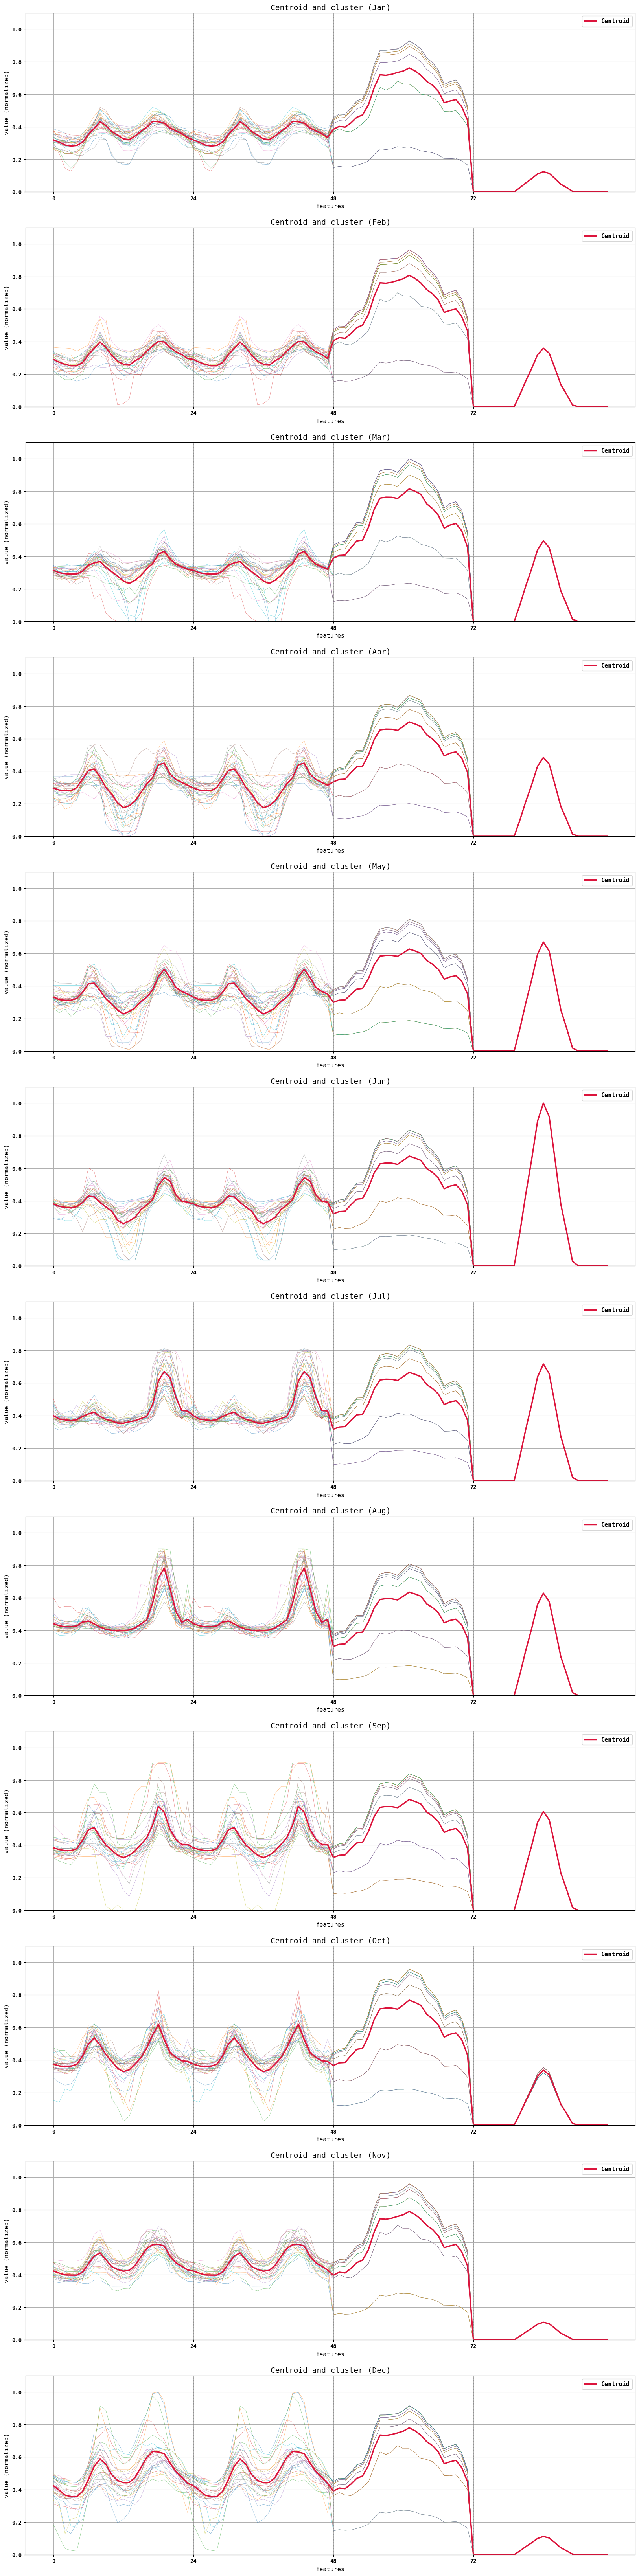

In [15]:
if run_kmeans or run_all:
    # # Example for a single month --------------------------------------------------
    # kmeans = KMeans(n_clusters=1, random_state=0, n_init="auto").fit(dset_jan)
    # centroid_jan = kmeans.cluster_centers_
    # print(kmeans.cluster_centers_)
    # print(kmeans.labels_)
    # print(f'Inertia = {kmeans.inertia_}')

    # fig1, axs1 = plt.subplots(figsize = (20, 7))
    # for i in range(len(dset_jan[:, 0])):
    #     axs1.plot(range(0, 96), dset_jan[i, :].reshape(-1), linewidth=0.5, alpha=0.6)
    # axs1.plot(range(0, 96), centroid_jan.reshape(-1), color='crimson', linewidth=2.5, label='Centroid')   
    # axs1.set_xticks([data_type * 24 for data_type in range(4)])
    # axs1.set_xlabel('features')
    # axs1.set_ylabel('value (normalized)')
    # axs1.set_title('Centroid and cluster')
    # axs1.legend()
    # for data_type in range(1, 4):
    #     x_pos = data_type * 24
    #     axs1.axvline(
    #         x=x_pos, 
    #         color='gray',
    #         linestyle=':',
    #         linewidth=2,
    #         alpha=0.7
    #     )


    # Seprate clustering for every month -----------------------------------------------------
    C_ele_typdays_n = np.zeros([12, 24])
    C_ele_sell_typdays_n = np.zeros([12, 24])
    P_load_typdays_n = np.zeros([12, 24])
    P_pv_typdays_n = np.zeros([12, 24])

    figM, axsM = plt.subplots(12, 1, figsize = (20, 7*12))

    for m in range(0, 12):
        dset_month = monthly_data_tuple[m]
        kmeans = KMeans(n_clusters=1, random_state=0, n_init="auto").fit(dset_month)
        centroid = kmeans.cluster_centers_.flatten()
        
        # Separation by data type
        C_ele_typdays_n[m, :] = centroid[0:24]
        C_ele_sell_typdays_n[m, :] = centroid[24:48]
        P_load_typdays_n[m, :] = centroid[48:72]
        P_pv_typdays_n[m, :] = centroid[72:96]

        # Manual evaluation of inertia
        manual_iner = 0
        for i in range(len(dset_month[:, 0])):
            manual_iner += sum((centroid - dset_month[i, :]) ** 2)

        print(f'Inertia for {months_names[m]} = {kmeans.inertia_}')
        # print(f'Manually evaluated inertia for {months_names[m]} = {manual_iner}')  # it's the same as kmeans.inertia_

        for i in range(len(dset_month[:, 0])):
            axsM[m].plot(range(0, 96), dset_month[i, :].reshape(-1), linewidth=0.5, alpha=0.6)
        axsM[m].plot(range(0, 96), centroid.reshape(-1), color='crimson', linewidth=2.5, label='Centroid')   
        axsM[m].set_xticks([data_type * 24 for data_type in range(4)])
        axsM[m].set_ylim(0, 1.1)
        axsM[m].set_xlabel('features')
        axsM[m].set_ylabel('value (normalized)')
        axsM[m].set_title(f'Centroid and cluster ({months_names[m]})')
        axsM[m].legend()
        for data_type in range(1, 4):
            x_pos = data_type * 24
            axsM[m].axvline(
                x=x_pos, 
                color='gray',
                linestyle=':',
                linewidth=2,
                alpha=0.7
            )

### KMedoids Clustering

Inertia for Jan = 22.781540383028243
Manually evaluated inertia for Jan = 30.61521058705655
Inertia for Feb = 20.323280673446213
Manually evaluated inertia for Feb = 27.788238139516473
Inertia for Mar = 26.996362494579365
Manually evaluated inertia for Mar = 41.51365047750004
Inertia for Apr = 26.764101111568536
Manually evaluated inertia for Apr = 36.40243267030604
Inertia for May = 27.551237984206516
Manually evaluated inertia for May = 36.61350603390174
Inertia for Jun = 24.43530820105483
Manually evaluated inertia for Jun = 31.49622604268872
Inertia for Jul = 25.96063497284229
Manually evaluated inertia for Jul = 38.799079321758946
Inertia for Aug = 25.629280346432346
Manually evaluated inertia for Aug = 34.288179796016465
Inertia for Sep = 29.12449294566646
Manually evaluated inertia for Sep = 40.40382295866558
Inertia for Oct = 28.626919101949614
Manually evaluated inertia for Oct = 41.87558347516055
Inertia for Nov = 24.523251768668352
Manually evaluated inertia for Nov = 34.500

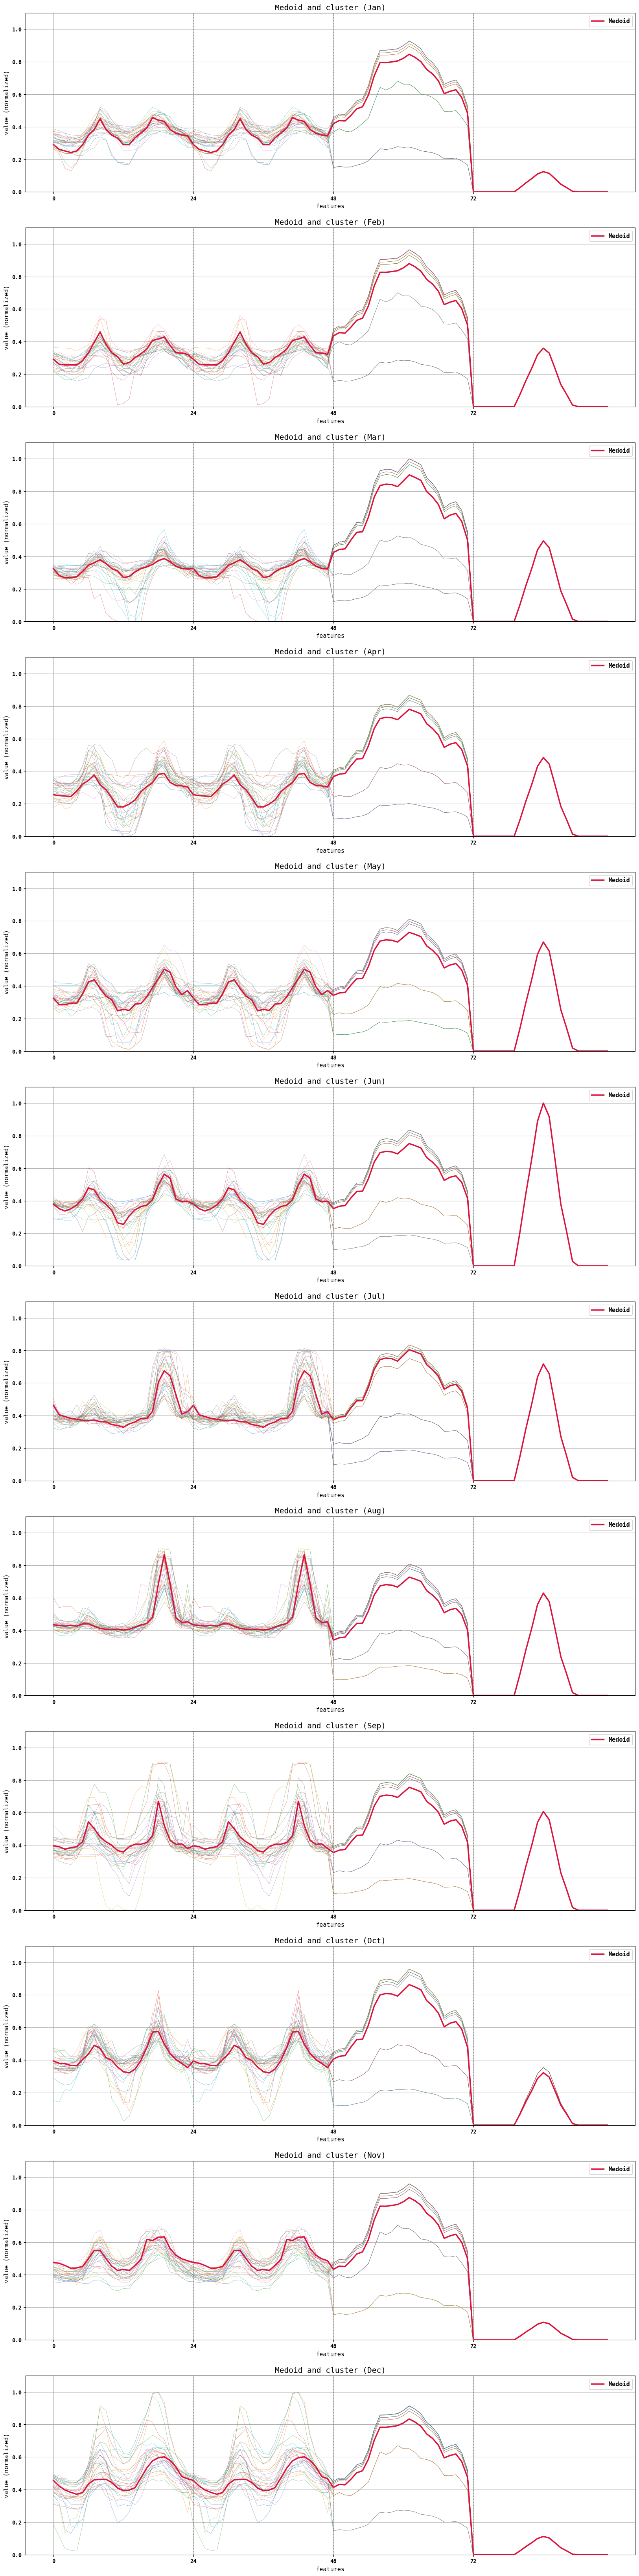

In [16]:
if run_kmedoids or run_all:
    # Seprate clustering for every month -----------------------------------------------------
    C_ele_typdays_n = np.zeros([12, 24])
    C_ele_sell_typdays_n = np.zeros([12, 24])
    P_load_typdays_n = np.zeros([12, 24])
    P_pv_typdays_n = np.zeros([12, 24])

    figM, axsM = plt.subplots(12, 1, figsize = (20, 7*12))

    for m in range(0, 12):
        dset_month = monthly_data_tuple[m]
        kmedoid = KMedoids(n_clusters=1, method='pam', metric='euclidean', random_state=0, max_iter=0).fit(dset_month)
        medoid = kmedoid.cluster_centers_.flatten()
        
        # Separation by data type
        C_ele_typdays_n[m, :] = medoid[0:24]
        C_ele_sell_typdays_n[m, :] = medoid[24:48]
        P_load_typdays_n[m, :] = medoid[48:72]
        P_pv_typdays_n[m, :] = medoid[72:96]

        # Manual evaluation of inertia
        manual_iner = 0
        for i in range(len(dset_month[:, 0])):
            manual_iner += sum((medoid - dset_month[i, :]) ** 2)

        print(f'Inertia for {months_names[m]} = {kmedoid.inertia_}')
        print(f'Manually evaluated inertia for {months_names[m]} = {manual_iner}')
        # manual_iner is not the same as kmedoids.inertia_, as, when using ".inertia_", the KMedoids package evaluates the L1 norm
        # (sum of the absolute values) instead of the L2 norm (sum of the squared errors / Euclidian norm). KMeans evaluates the L2 norm

        for i in range(len(dset_month[:, 0])):
            axsM[m].plot(range(0, 96), dset_month[i, :].reshape(-1), linewidth=0.5, alpha=0.6)
        axsM[m].plot(range(0, 96), medoid.reshape(-1), color='crimson', linewidth=2.5, label='Medoid')
        axsM[m].set_xticks([data_type * 24 for data_type in range(4)])
        axsM[m].set_ylim(0, 1.1)
        axsM[m].set_xlabel('features')
        axsM[m].set_ylabel('value (normalized)')
        axsM[m].set_title(f'Medoid and cluster ({months_names[m]})')
        axsM[m].legend()
        for data_type in range(1, 4):
            x_pos = data_type * 24
            axsM[m].axvline(
                x=x_pos, 
                color='gray',
                linestyle=':',
                linewidth=2,
                alpha=0.7
            )

#### De-normalization of the typical days data (centroids or medoids)

In [17]:
# De-normalizing the typical day data -----------------------
print(maximums_list)
C_ele_typdays = C_ele_typdays_n * maximums_list[0]
C_ele_sell_typdays = C_ele_typdays_n * maximums_list[1]
P_load_typdays = P_load_typdays_n * maximums_list[2]
P_pv_typdays = P_pv_typdays_n * maximums_list[3]

[277.0, 138.5, 1.422363129999999, 3.633937425]


### Scaling the data to match yearly totals
The data is scaled slightly so that, referring for example to the PV generation, the total amount of energy generated during the year, evaluated from the original data, is equal to the sum of the energy generated in each typical day multiplied by the number of days in the corresponding month. 

In [18]:
if run_scaledata or run_all:
    # Dnum = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31] 

    scale_fac_Cele = sum(C_ele) / sum(Dnum[d] * sum(C_ele_typdays[d, :]) for d in range(len(Dnum)))
    scale_fac_Celesell = sum(C_ele_sell) / sum(Dnum[d] * sum(C_ele_sell_typdays[d, :]) for d in range(len(Dnum)))
    scale_fac_Pload = sum(P_load) / sum(Dnum[d] * sum(P_load_typdays[d, :]) for d in range(len(Dnum)))
    scale_fac_Ppv = sum(P_pv) / sum(Dnum[d] * sum(P_pv_typdays[d, :]) for d in range(len(Dnum)))

    C_ele_typdays_scaled = C_ele_typdays * scale_fac_Cele
    C_ele_sell_typdays_scaled = C_ele_sell_typdays * scale_fac_Cele
    P_load_typdays_scaled = P_load_typdays * scale_fac_Cele
    P_pv_typdays_scaled = P_pv_typdays * scale_fac_Cele